# One-seed candidate diagnostics

This notebook studies which unseeded Graph-A vertex should be queried next. Predictor columns contain only information available before the query. Revealed correspondences, gradient changes, and SGM results are outcomes.

The main diagnostic chain is:

1. candidate features;
2. change in the first-gradient true-match margin;
3. change in common-set first-direction accuracy;
4. change in common-set final accuracy.

All results are exploratory within one fixed graph pair and existing seed set. Random candidate splits do not establish generalization to a new graph pair.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True})


In [2]:
# Choose one: "sparse_er", "sparse_sbm", or "paper"
PROBLEM = "paper"

EXPERIMENT_DIR = Path.cwd().resolve()
if EXPERIMENT_DIR.name != "one_seed_marginal_problem":
    EXPERIMENT_DIR = EXPERIMENT_DIR / "one_seed_marginal_problem"
DATA_DIR = EXPERIMENT_DIR / "data"
RANDOM_STATE = 42
TEST_FRACTION = 0.30


## Load the pre-query features and post-query outcomes


In [3]:
feature_path = DATA_DIR / f"{PROBLEM}_candidate_features.csv"
outcome_path = DATA_DIR / f"{PROBLEM}_candidate_outcomes.csv"
metadata_path = DATA_DIR / f"{PROBLEM}_metadata.json"

features = pd.read_csv(feature_path)
outcomes = pd.read_csv(outcome_path)
metadata = json.loads(metadata_path.read_text())
join_keys = ["problem", "candidate_vertex_graph1"]

data = features.merge(outcomes, on=join_keys, validate="one_to_one")
feature_columns = [
    column
    for column in metadata["feature_columns"]
    if column in data and data[column].nunique(dropna=True) > 1
]
data["outcome_success"] = data["outcome_success"].astype(int)

print(f"Problem: {PROBLEM}")
print(f"Candidates: {len(data):,}")
print(f"Pre-query features: {len(feature_columns)}")
print(f"Successful candidates: {data['outcome_success'].mean():.1%}")
print(
    "Baseline final accuracy: "
    f"{metadata['baseline_sgm']['final_unseeded_accuracy']:.3f}"
)


Problem: paper
Candidates: 286
Pre-query features: 14
Successful candidates: 51.7%
Baseline final accuracy: 0.409


## Outcome distributions

The common-set changes compare the baseline and augmented SGM runs on exactly the same remaining vertices.


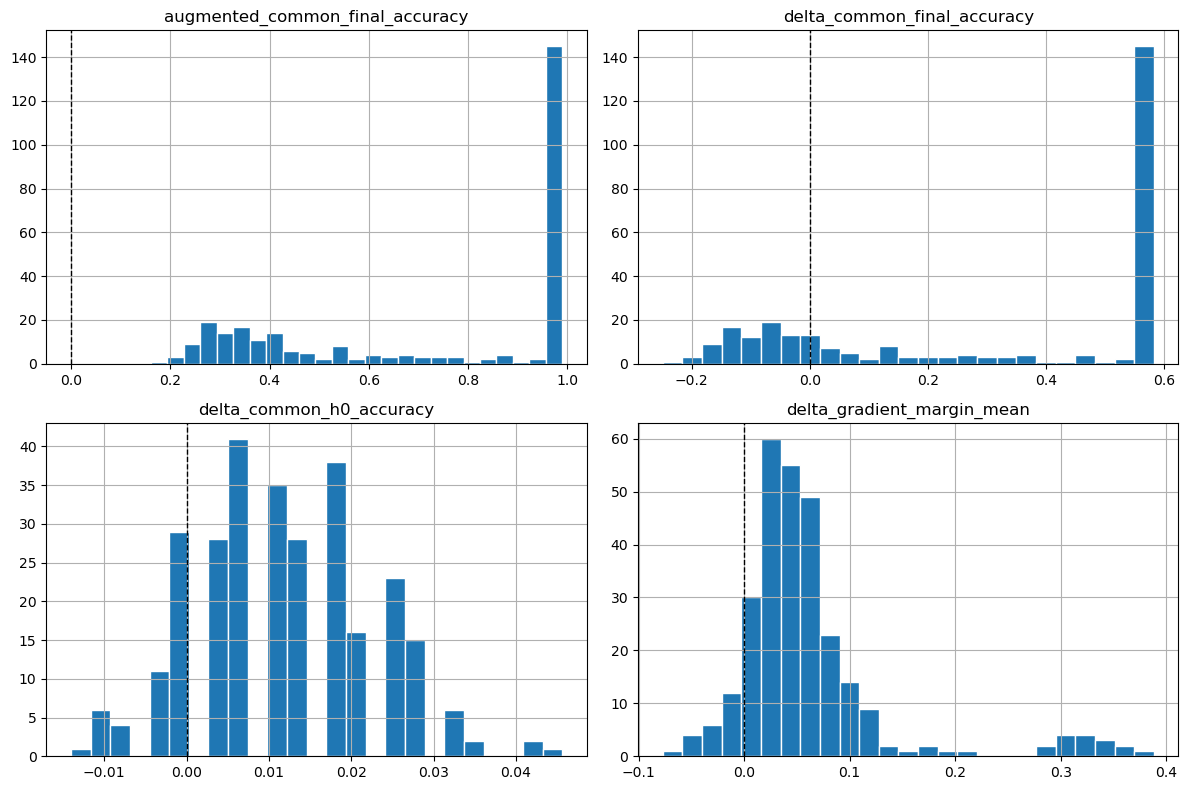

,augmented_common_final_accuracy,delta_common_final_accuracy,delta_common_h0_accuracy,delta_gradient_margin_mean
count,286.0000,286.0000,286.0000,286.0000
mean,0.7148,0.3057,0.0118,0.0607
std,0.2986,0.2986,0.0105,0.0765
min,0.1614,-0.2491,-0.0140,-0.0771
25%,0.3833,-0.0246,0.0035,0.0211
50%,0.9649,0.5544,0.0105,0.0445
75%,0.9789,0.5684,0.0175,0.0694
max,0.9895,0.5825,0.0456,0.3883


In [4]:
outcome_columns = [
    "augmented_common_final_accuracy",
    "delta_common_final_accuracy",
    "delta_common_h0_accuracy",
    "delta_gradient_margin_mean",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, column in zip(axes.ravel(), outcome_columns):
    ax.hist(data[column], bins=25, edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(column)
plt.tight_layout()
plt.show()

display(data[outcome_columns].describe().round(4))


## Feature associations

Spearman correlations describe monotone relationships and do not require a linear relationship.


In [5]:
diagnostic_targets = [
    "delta_gradient_margin_mean",
    "delta_common_h0_accuracy",
    "delta_common_final_accuracy",
]

associations = pd.DataFrame(
    {
        target: [
            data[column].corr(data[target], method="spearman")
            for column in feature_columns
        ]
        for target in diagnostic_targets
    },
    index=feature_columns,
)
associations["maximum_absolute_association"] = associations.abs().max(axis=1)
display(
    associations.sort_values(
        "maximum_absolute_association", ascending=False
    ).round(3)
)


,delta_gradient_margin_mean,delta_common_h0_accuracy,delta_common_final_accuracy,maximum_absolute_association
candidate_degree_percentile,0.522,0.194,0.165,0.522
candidate_signature_collision_reduction,0.456,0.157,0.123,0.456
candidate_new_one_hop_coverage_fraction,0.426,0.149,0.117,0.426
candidate_core_percentile,0.383,0.191,0.189,0.383
candidate_mean_nearest_seed_distance_reduction,0.378,0.141,0.103,0.378
candidate_new_second_witness_fraction,0.310,0.146,0.134,0.310
candidate_new_two_hop_coverage_fraction,0.296,0.127,0.070,0.296
candidate_gradient_row_top2_gap_z,0.233,0.007,0.038,0.233
candidate_seed_signature_agreement_gap,0.173,-0.060,-0.017,0.173
candidate_seed_signature_best_agreement,0.040,-0.077,-0.075,0.077


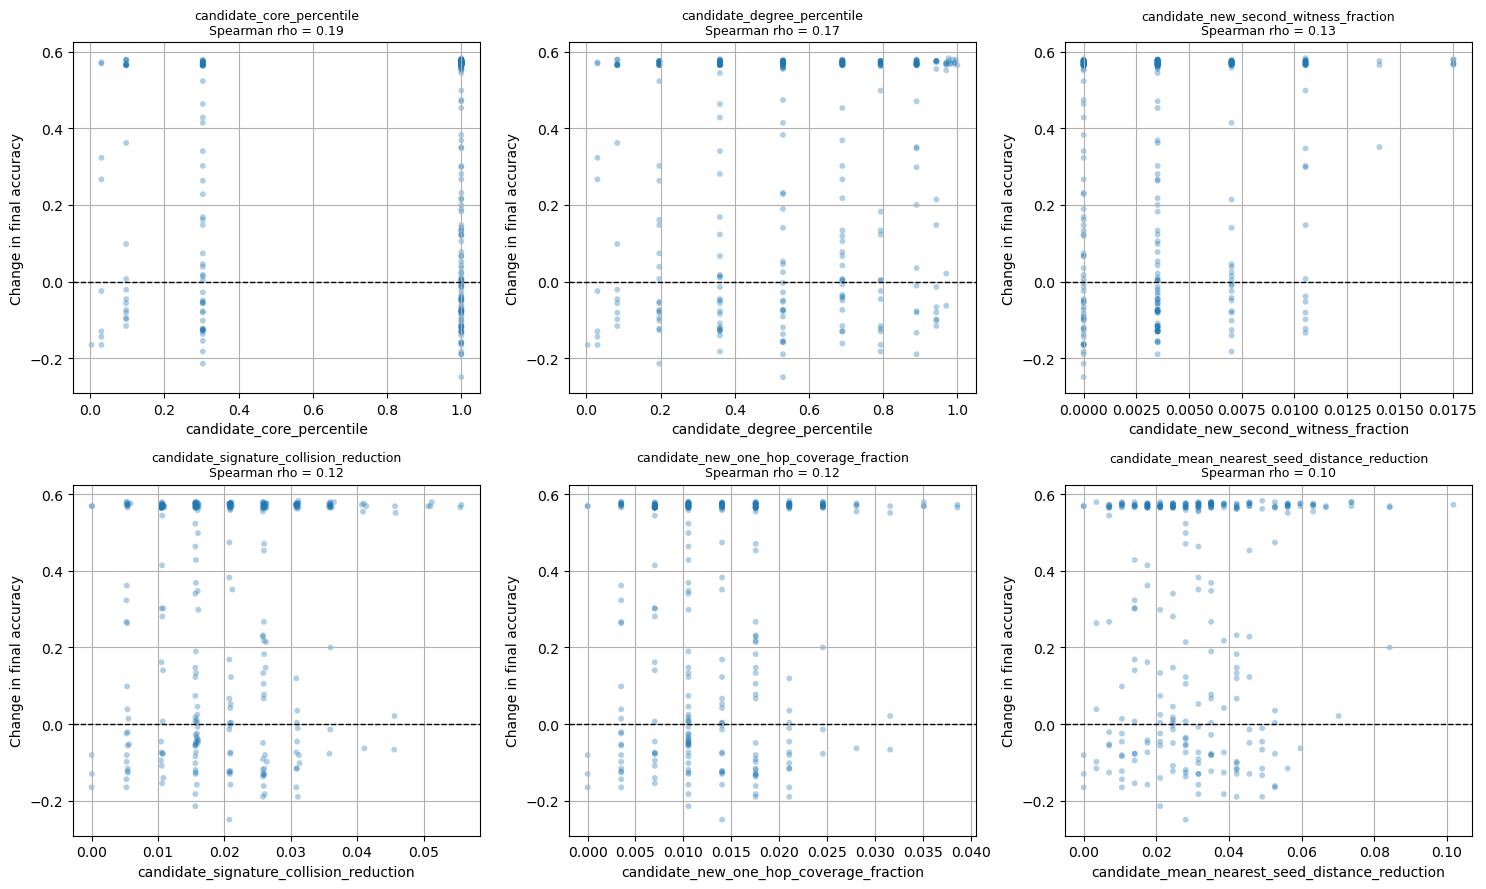

In [6]:
top_features = (
    associations["delta_common_final_accuracy"]
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, column in zip(axes.ravel(), top_features):
    ax.scatter(
        data[column],
        data["delta_common_final_accuracy"],
        s=18,
        alpha=0.35,
        edgecolors="none",
    )
    correlation = data[column].corr(
        data["delta_common_final_accuracy"], method="spearman"
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{column}\nSpearman rho = {correlation:.2f}", fontsize=9)
    ax.set_xlabel(column)
    ax.set_ylabel("Change in final accuracy")
plt.tight_layout()
plt.show()


## Gradient diagnostic chain

If the proposed mechanism is correct, helpful candidates should first improve true-match gradient margins, then improve the first assignment direction, and finally improve the completed matching.


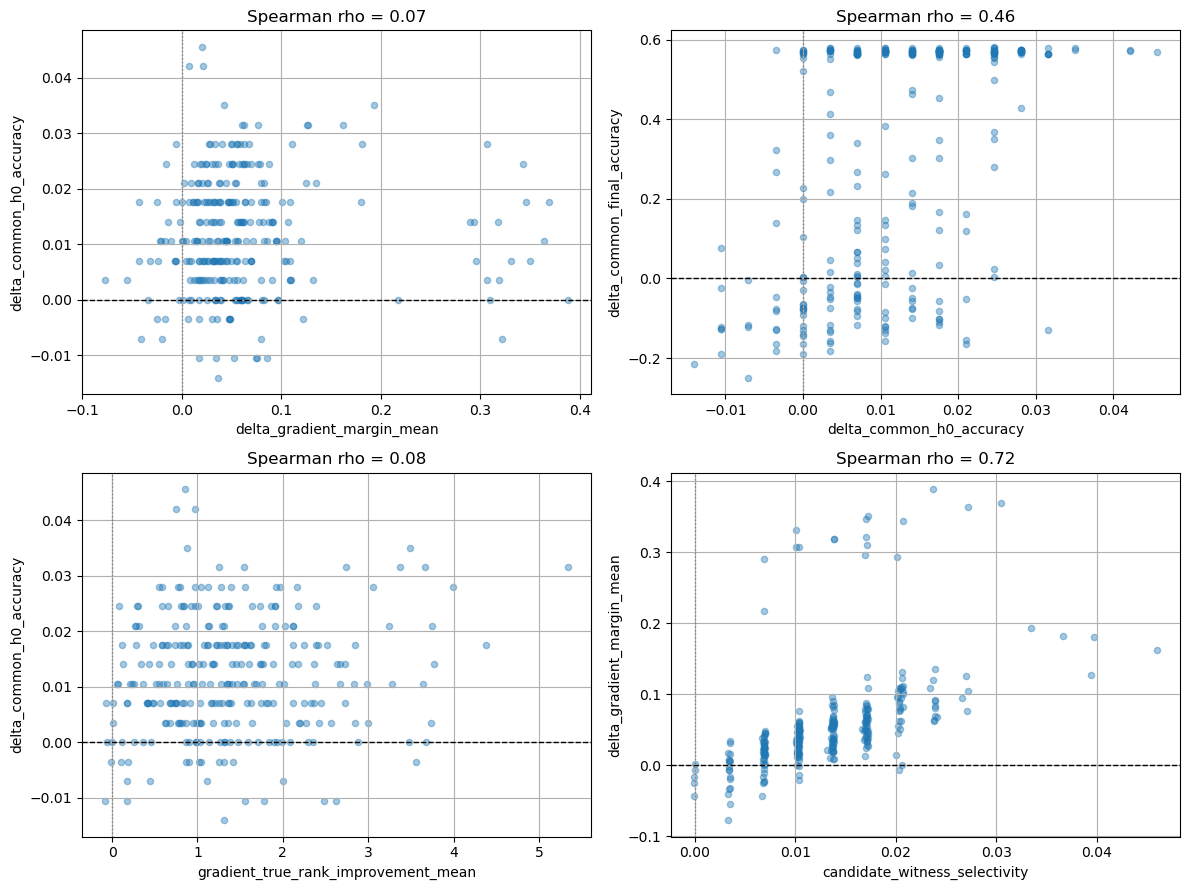

,first_direction_wrong_to_right_count,first_direction_right_to_wrong_count,delta_common_h0_accuracy,delta_common_final_accuracy
first_direction_wrong_to_right_count,1.000,0.169,0.845,0.368
first_direction_right_to_wrong_count,0.169,1.000,-0.350,-0.222
delta_common_h0_accuracy,0.845,-0.350,1.000,0.459
delta_common_final_accuracy,0.368,-0.222,0.459,1.000


In [7]:
chain_pairs = [
    ("delta_gradient_margin_mean", "delta_common_h0_accuracy"),
    ("delta_common_h0_accuracy", "delta_common_final_accuracy"),
    ("gradient_true_rank_improvement_mean", "delta_common_h0_accuracy"),
    ("candidate_witness_selectivity", "delta_gradient_margin_mean"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (x_column, y_column) in zip(axes.ravel(), chain_pairs):
    ax.scatter(data[x_column], data[y_column], s=20, alpha=0.40)
    correlation = data[x_column].corr(data[y_column], method="spearman")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"Spearman rho = {correlation:.2f}")
    ax.set_xlabel(x_column)
    ax.set_ylabel(y_column)
plt.tight_layout()
plt.show()

transition_summary = data[
    [
        "first_direction_wrong_to_right_count",
        "first_direction_right_to_wrong_count",
        "delta_common_h0_accuracy",
        "delta_common_final_accuracy",
    ]
].corr(method="spearman")
display(transition_summary.round(3))


## Exploratory prediction and ranking

The held-out candidates belong to the same graph. These results measure within-problem discrimination only.


In [8]:
train, test = train_test_split(
    data,
    test_size=TEST_FRACTION,
    random_state=RANDOM_STATE,
    stratify=data["outcome_success"],
)

classifier = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
regressor = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

classifier.fit(train[feature_columns], train["outcome_success"])
regressor.fit(train[feature_columns], train["delta_common_final_accuracy"])

success_probability = classifier.predict_proba(test[feature_columns])[:, 1]
success_prediction = (success_probability >= 0.5).astype(int)
predicted_improvement = regressor.predict(test[feature_columns])

model_metrics = pd.DataFrame(
    {
        "value": {
            "classification ROC AUC": roc_auc_score(
                test["outcome_success"], success_probability
            ),
            "classification average precision": average_precision_score(
                test["outcome_success"], success_probability
            ),
            "classification balanced accuracy": balanced_accuracy_score(
                test["outcome_success"], success_prediction
            ),
            "regression R2": r2_score(
                test["delta_common_final_accuracy"], predicted_improvement
            ),
            "regression MAE": mean_absolute_error(
                test["delta_common_final_accuracy"], predicted_improvement
            ),
            "regression rank correlation": pd.Series(predicted_improvement).corr(
                pd.Series(test["delta_common_final_accuracy"].to_numpy()),
                method="spearman",
            ),
        }
    }
)
display(model_metrics.round(4))


,value
classification ROC AUC,0.6068
classification average precision,0.6862
classification balanced accuracy,0.5827
regression R2,-0.0138
regression MAE,0.2757
regression rank correlation,0.0504


In [9]:
ranked_test = test[
    [
        "candidate_vertex_graph1",
        "outcome_success",
        "augmented_common_final_accuracy",
        "delta_common_final_accuracy",
    ]
].copy()
ranked_test["predicted_success_probability"] = success_probability
ranked_test = ranked_test.sort_values(
    "predicted_success_probability", ascending=False
)

ranking_rows = []
for fraction in [0.05, 0.10, 0.20]:
    count = max(1, int(np.ceil(fraction * len(ranked_test))))
    selected = ranked_test.head(count)
    ranking_rows.append(
        {
            "top_fraction": fraction,
            "selected_count": count,
            "selected_success_rate": selected["outcome_success"].mean(),
            "selected_mean_final_accuracy": selected[
                "augmented_common_final_accuracy"
            ].mean(),
            "selected_mean_improvement": selected[
                "delta_common_final_accuracy"
            ].mean(),
        }
    )

display(pd.DataFrame(ranking_rows).round(4))
display(ranked_test.head(10))


,top_fraction,selected_count,selected_success_rate,selected_mean_final_accuracy,selected_mean_improvement
0,0.05,5,0.8000,0.8681,0.4604
1,0.10,9,0.8889,0.9154,0.5068
2,0.20,18,0.7778,0.8620,0.4530


,candidate_vertex_graph1,outcome_success,augmented_common_final_accuracy,delta_common_final_accuracy,predicted_success_probability
95,103,1,0.975439,0.568421,0.839096
49,53,1,0.975439,0.564912,0.827683
248,260,0,0.428070,0.021053,0.818314
57,63,1,0.975439,0.568421,0.785248
225,236,1,0.985965,0.578947,0.782229
78,84,1,0.975439,0.564912,0.757626
222,233,1,0.964912,0.554386,0.756593
266,279,1,0.982456,0.571930,0.728951
0,0,1,0.975439,0.568421,0.717115
53,58,1,0.975439,0.564912,0.716970


,feature,importance_mean,importance_std
1,candidate_core_percentile,0.0260,0.0262
13,candidate_gradient_row_normalized_entropy,0.0219,0.0074
12,candidate_gradient_row_top2_gap_z,0.0165,0.0094
2,candidate_edges_to_existing_seeds,0.0133,0.0045
7,candidate_signature_collision_reduction,0.0123,0.0311
5,candidate_new_two_hop_coverage_fraction,0.0072,0.0153
9,candidate_existing_seed_community_fraction,0.0057,0.0083
4,candidate_new_second_witness_fraction,0.0053,0.0109
6,candidate_mean_nearest_seed_distance_reduction,0.0019,0.0095
10,candidate_seed_signature_best_agreement,0.0000,0.0000


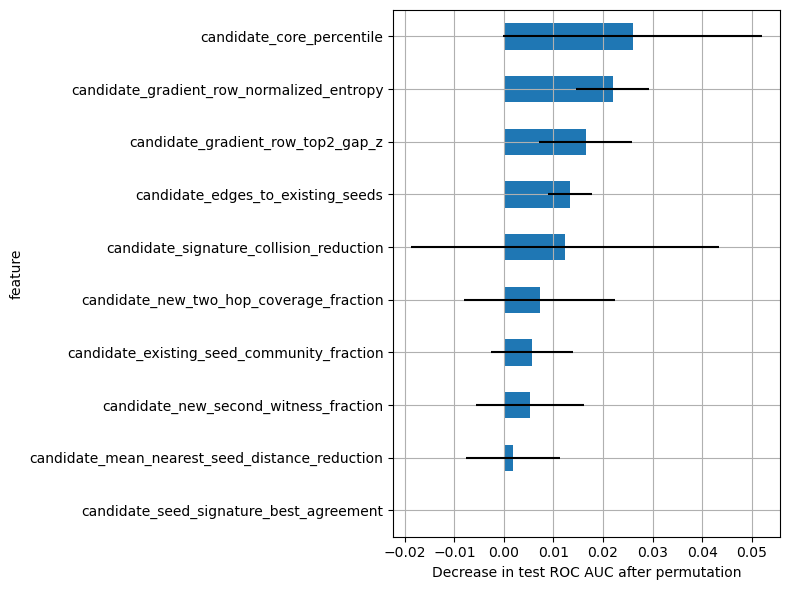

In [10]:
importance = permutation_importance(
    classifier,
    test[feature_columns],
    test["outcome_success"],
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_table = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    }
).sort_values("importance_mean", ascending=False)
display(importance_table.round(4))

importance_table.head(10).sort_values("importance_mean").plot.barh(
    x="feature",
    y="importance_mean",
    xerr="importance_std",
    legend=False,
    figsize=(8, 6),
)
plt.xlabel("Decrease in test ROC AUC after permutation")
plt.tight_layout()
plt.show()


## Questions to answer

1. Which pre-query features are associated with improved gradient margins?
2. Does gradient-margin improvement lead to a better first direction?
3. Does a better first direction lead to better final matching?
4. Do the highest-ranked candidates outperform random candidate selection?
5. Are the same relationships present in ER, SBM, and PAPER problems?
